The dataset is the entire script for the video game Final Fantasy XIV; for context, the spoken dialogue is longer than War and Peace, so it is reasonably long enough for this experiment. The inputs is the script as a text file with lines formatted as “Name: dialogue”, which is turned into a DataFrame as an output.

Lines less than four words long were ignored so that characters’ unique ways of speaking were more visible; the loss in data size was well worth the tradeoff for quality.

6 speakers were chosen based on their unique mannerisms and large amounts of dialogue; all other dialogue was discarded. Thus there were 9,780 total lines, split 80/10/10 for training/validation/testing.




# The first cell requires you to click the Choose Files button after running, then FFXIV_Dialogue.txt which is included in the zip

In [ ]:
#All the glorious imports we eventually use
from google.colab import files
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
import re
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

#You need to upload FFXIV_Dialogue.txt for the rest to run. It is included in the .zip
uploaded_files = files.upload()


Saving FFXIV_Dialogue.txt to FFXIV_Dialogue (4).txt


=== Overall word statistics ===
Total lines in filtered dataset: 9780
Total words in filtered dataset: 173153
Total unique words in entire script: 18302
Average words per line: 17.70

=== Line counts per speaker ===
  Alphinaud: 2518
  Y'shtola: 1563
  Alisaie: 2189
  Urianger: 1127
  G'raha Tia: 1713
  Emet-Selch: 670


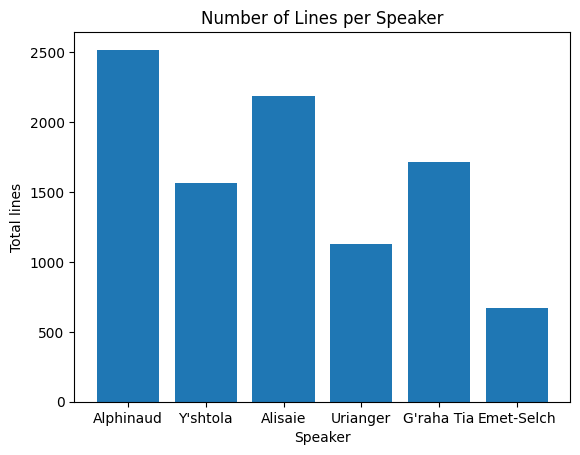

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
# Normalizes speaker names from the raw script.
def normalize_speaker(name: str) -> str:
    name = name.strip()
    name = name.replace("’", "'")
    if name.startswith("Crystal Exarch"):
        return "G'raha Tia"
    return name

def tokenize_words(text: str):
    return re.findall(r"[A-Za-z']+", text.lower())

# Characters used as class labels in the model
speaker_whitelist = {
    "Emet-Selch",
    "Alphinaud",
    "Y'shtola",
    "Alisaie",
    "Urianger",
    "G'raha Tia",
}

# Data structures for analysis
filtered_rows = [] # rows kept for the ML dataset
line_counts = Counter() # number of lines per speaker
speaker_token_counts = Counter() # total word count per speaker
speaker_word_freqs = defaultdict(Counter)
all_script_words = set()                  # unique words in the entire script

# Single pass over the whole script file
with open("FFXIV_Dialogue.txt", "r", encoding="utf-8", errors="ignore") as f:
    for raw_line in f:
        line = raw_line.strip()
        if not line or ":" not in line:
            continue

        raw_speaker, raw_text = line.split(":", 1)
        text = raw_text.strip()
        if not text:
            continue

        # Tokens for global stats (all speakers, even those not in whitelist)
        tokens = tokenize_words(text)
        for word in tokens:
            all_script_words.add(word)

        # Normalize speaker name and keep only target characters
        speaker = normalize_speaker(raw_speaker)
        if speaker not in speaker_whitelist:
            continue

        # Filter out very short lines (fewer than 4 words)
        if len(tokens) < 4:
            continue

        # Add this line to the supervised dataset
        filtered_rows.append({"speaker": speaker, "text": text})

        # Update per-speaker statistics
        line_counts[speaker] += 1
        speaker_token_counts[speaker] += len(tokens)
        for word in tokens:
            speaker_word_freqs[speaker][word] += 1

# Turn filtered_rows into a DataFrame used later for splits and modeling
dialogue_df = pd.DataFrame(filtered_rows)

if dialogue_df.empty:
    print("Warning: filtered dataset is empty. Check whitelist names and filters.")
else:
    # Preferred order for reporting
    preferred_order = [
        "Alphinaud",
        "Y'shtola",
        "Alisaie",
        "Urianger",
        "G'raha Tia",
        "Emet-Selch",
    ]
    present_speakers = list(dialogue_df["speaker"].unique())
    speaker_order = [s for s in preferred_order if s in present_speakers] + \
                    [s for s in present_speakers if s not in preferred_order]

    total_lines_all = len(dialogue_df)
    total_words_all = sum(speaker_token_counts.values())
    avg_words_per_line = (
        total_words_all / total_lines_all if total_lines_all > 0 else 0.0
    )

    print("=== Overall word statistics ===")
    print(f"Total lines in filtered dataset: {total_lines_all}")
    print(f"Total words in filtered dataset: {total_words_all}")
    print(f"Total unique words in entire script: {len(all_script_words)}")
    print(f"Average words per line: {avg_words_per_line:.2f}")

    print("\n=== Line counts per speaker ===")
    for s in speaker_order:
        print(f"{s}: {line_counts[s]}")

    # Simple bar plot of lines per speaker
    plt.bar(speaker_order, [line_counts[s] for s in speaker_order])
    plt.xlabel("Speaker")
    plt.ylabel("Total lines")
    plt.title("Number of Lines per Speaker")
    plt.show()


In [ ]:
# Splits into train/validation/test
# Split is 80 percent train, 10 percent validation, 10 percent test.
train_df, temp_df = train_test_split(
    dialogue_df,
    test_size=0.2,
    stratify=dialogue_df["speaker"],
    random_state=42,
)
#Splits extra 20% into 10% val 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["speaker"],
    random_state=42,
)
print("Number of lines:")
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
# Helper to pretty-print counts
def print_counts(title, series):
    print(f"\n{title}")
    for speaker_name, count in series.items():
        print(f"{speaker_name}: {count}")

print_counts("Train lines:", train_df["speaker"].value_counts())
print_counts("Val lines:",   val_df["speaker"].value_counts())
print_counts("Test lines:",  test_df["speaker"].value_counts())


# Save the split so it is easy to reload and include in the final submission.
train_df.to_csv("ffxiv_train.csv", index=False)
val_df.to_csv("ffxiv_val.csv", index=False)
test_df.to_csv("ffxiv_test.csv", index=False)

Number of lines:
Train: 7824 Val: 978 Test: 978

Train lines:
Alphinaud: 2015
Alisaie: 1751
G'raha Tia: 1370
Y'shtola: 1250
Urianger: 902
Emet-Selch: 536

Val lines:
Alphinaud: 251
Alisaie: 219
G'raha Tia: 172
Y'shtola: 157
Urianger: 112
Emet-Selch: 67

Test lines:
Alphinaud: 252
Alisaie: 219
G'raha Tia: 171
Y'shtola: 156
Urianger: 113
Emet-Selch: 67


#The model accuracy finished at a ~40% chance to correctly determine which character spoke the line after 10 epochs. This is 250% as accurate as guessing at random (16.7%)

In [ ]:
# Reload the data splits for the modeling section.
train_df = pd.read_csv("ffxiv_train.csv")
val_df   = pd.read_csv("ffxiv_val.csv")
test_df  = pd.read_csv("ffxiv_test.csv")

print("Train size:", len(train_df), "\nVal size:", len(val_df), "\nTest size:", len(test_df))


Train size: 7824 
Val size: 978 
Test size: 978


In [ ]:
# Build label mappings from speaker names to integer IDs and back.
speaker_names = sorted(train_df["speaker"].unique())
label2id = {name: i for i, name in enumerate(speaker_names)}
id2label = {i: name for name, i in label2id.items()}

num_classes = len(label2id)


In [ ]:
# Tokenizer that splits on whitespace and lowercases words.
def tokenize_for_vocab(text: str):
    return text.lower().split()

# Build a word frequency counter over the training set.
word_freq = Counter()
for line_text in train_df["text"]:
    word_freq.update(tokenize_for_vocab(line_text))

# Cap the vocabulary size to keep the model compact.
vocab_limit = 20000
most_common_words = word_freq.most_common(vocab_limit)

word2id = {"<pad>": 0, "<unk>": 1}
for idx, (word, _) in enumerate(most_common_words, start=2):
    word2id[word] = idx

id2word = {i: w for w, i in word2id.items()}
vocab_size = len(word2id)
print("Vocab size:", vocab_size)

Vocab size: 17370


In [ ]:
# Maximum sequence length in words for each dialogue line.
MAX_LENGTH = 40

# Encode one line of text into a tensor of word IDs.
def encode_text(text: str, max_len: int = MAX_LENGTH):
    words = tokenize_for_vocab(text)
    word_ids = [word2id.get(w, word2id["<unk>"]) for w in words[:max_len]]
    if len(word_ids) < max_len:
        word_ids += [word2id["<pad>"]] * (max_len - len(word_ids))
    return torch.tensor(word_ids, dtype=torch.long)

In [ ]:
# Dataset wrapper that exposes each row as (encoded line, label ID).
class FFXIVDialogueDataset(Dataset):
    def __init__(self, df, label2id, max_len: int = MAX_LENGTH):
        self.df = df.reset_index(drop=True)
        self.label2id = label2id
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = row["text"]
        speaker_name = row["speaker"]

        input_ids = encode_text(text, self.max_len)
        label_id = self.label2id[speaker_name]
        return input_ids, torch.tensor(label_id, dtype=torch.long)


In [ ]:
# Build the PyTorch datasets and data loaders.
batch_size = 64
#Creates datasets formally
train_dataset = FFXIVDialogueDataset(train_df, label2id)
val_dataset   = FFXIVDialogueDataset(val_df,   label2id)
test_dataset  = FFXIVDialogueDataset(test_df,  label2id)
#Create DataLoaders for performance
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size)

batch_inputs, batch_labels = next(iter(train_loader))

In [ ]:
# Choose GPU if available, otherwise fall back to CPU.
# This keeps the rest of the code device-agnostic.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Bidirectional LSTM classifier that predicts which speaker produced a dialogue line.
class FFXIVLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes, pad_idx):
        super().__init__()

        # Embedding layer maps word IDs to dense vector representations.
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx,
        )

        # Single-layer bidirectional LSTM processes the sequence of word embeddings.
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        # Dropout reduces overfitting by randomly zeroing out some activations.
        self.dropout = nn.Dropout(p=0.5)

        # Final linear layer maps the concatenated forward/backward hidden state to class scores.
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, input_ids):
        # input_ids has shape [batch_size, sequence_length].
        # First step is a lookup in the embedding table.
        embedded_words = self.embedding(input_ids)       # [batch_size, seq_len, embedding_dim]

        # LSTM returns output for each time step and the final hidden and cell states.
        # final_hidden_states has shape [num_directions, batch_size, hidden_size].
        _, (final_hidden_states, _) = self.lstm(embedded_words)

        # For a bidirectional LSTM, index -2 is the last forward state and -1 is the last backward state.
        forward_hidden = final_hidden_states[-2]         # [batch_size, hidden_size]
        backward_hidden = final_hidden_states[-1]        # [batch_size, hidden_size]

        # Concatenate forward and backward hidden states into a single representation.
        combined_hidden = torch.cat([forward_hidden, backward_hidden], dim=1)  # [batch_size, 2 * hidden_size]

        # Apply dropout and then the classifier to get one logit vector per example.
        combined_hidden = self.dropout(combined_hidden)
        logits = self.classifier(combined_hidden)        # [batch_size, num_classes]
        return logits


Using device: cpu


In [ ]:
# Instantiate the model and training setup.
embedding_dim = 64
hidden_size = 64
learning_rate = 1e-3
pad_idx = word2id["<pad>"]

model = FFXIVLSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_size=hidden_size,
    num_classes=num_classes,
    pad_idx=pad_idx,
).to(device)

# Cross-entropy loss is standard for multi-class speaker classification.
loss_function = nn.CrossEntropyLoss()

# Adam optimizer with weight decay applies L2 regularization to reduce overfitting.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4,
)



In [ ]:
# This function trains the model for one epoch over the training data.
def train_one_epoch(model, dataloader, optimizer, loss_function, device):
    model.train()
    epoch_loss_sum = 0.0
    correct_predictions = 0
    total_examples = 0

    for batch_inputs, batch_labels in dataloader:
        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        logits = model(batch_inputs)
        loss = loss_function(logits, batch_labels)
        loss.backward()
        optimizer.step()

        # Accumulate loss weighted by batch size for a proper average.
        epoch_loss_sum += loss.item() * batch_labels.size(0)

        # Compute number of correct predictions in this batch.
        batch_predictions = torch.argmax(logits, dim=1)
        correct_predictions += (batch_predictions == batch_labels).sum().item()
        total_examples += batch_labels.size(0)

    avg_epoch_loss = epoch_loss_sum / total_examples
    avg_epoch_accuracy = correct_predictions / total_examples
    return avg_epoch_loss, avg_epoch_accuracy


# This function evaluates the model on a validation or test set without gradients.
def evaluate(model, dataloader, loss_function, device):
    model.eval()
    eval_loss_sum = 0.0
    correct_predictions = 0
    total_examples = 0

    with torch.no_grad():
        for batch_inputs, batch_labels in dataloader:
            batch_inputs = batch_inputs.to(device)
            batch_labels = batch_labels.to(device)

            logits = model(batch_inputs)
            loss = loss_function(logits, batch_labels)

            eval_loss_sum += loss.item() * batch_labels.size(0)

            batch_predictions = torch.argmax(logits, dim=1)
            correct_predictions += (batch_predictions == batch_labels).sum().item()
            total_examples += batch_labels.size(0)

    avg_eval_loss = eval_loss_sum / total_examples
    avg_eval_accuracy = correct_predictions / total_examples
    return avg_eval_loss, avg_eval_accuracy


In [ ]:
import copy

# Training loop configuration with simple early stopping on validation loss.
num_epochs = 10
#Store the losses and accuracies of each epoch
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_loss = float("inf")
best_state_dict = None

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, loss_function, device)
    val_loss, val_acc = evaluate(model, val_loader, loss_function, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch:02d}/{num_epochs}: "
        f"Train Loss = {train_loss:.4f}, Train Acc = {train_acc:.4f}, "
        f"Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.4f}"
    )

# Load the best model parameters before evaluating on the test set.
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)


Epoch 01/10: Train Loss = 1.0478, Train Acc = 0.5923, Val Loss = 1.6412, Val Acc = 0.3671
Epoch 02/10: Train Loss = 0.8807, Train Acc = 0.6724, Val Loss = 1.7523, Val Acc = 0.3855
Epoch 03/10: Train Loss = 0.7325, Train Acc = 0.7251, Val Loss = 2.0221, Val Acc = 0.3814
Epoch 04/10: Train Loss = 0.5662, Train Acc = 0.7970, Val Loss = 2.2387, Val Acc = 0.3773
Epoch 05/10: Train Loss = 0.4368, Train Acc = 0.8535, Val Loss = 2.3995, Val Acc = 0.3661
Epoch 06/10: Train Loss = 0.3272, Train Acc = 0.8908, Val Loss = 2.6377, Val Acc = 0.3650
Epoch 07/10: Train Loss = 0.2399, Train Acc = 0.9279, Val Loss = 2.8264, Val Acc = 0.3650
Epoch 08/10: Train Loss = 0.1729, Train Acc = 0.9472, Val Loss = 3.0204, Val Acc = 0.3722
Epoch 09/10: Train Loss = 0.1581, Train Acc = 0.9513, Val Loss = 3.1067, Val Acc = 0.3855
Epoch 10/10: Train Loss = 0.1153, Train Acc = 0.9652, Val Loss = 3.1179, Val Acc = 0.3773


Final Train Loss: 1.199, Train Accuracy: 0.530
Final Val Loss: 1.577, Val Accuracy: 0.376
Final Test Loss: 1.555, Test Accuracy: 0.376


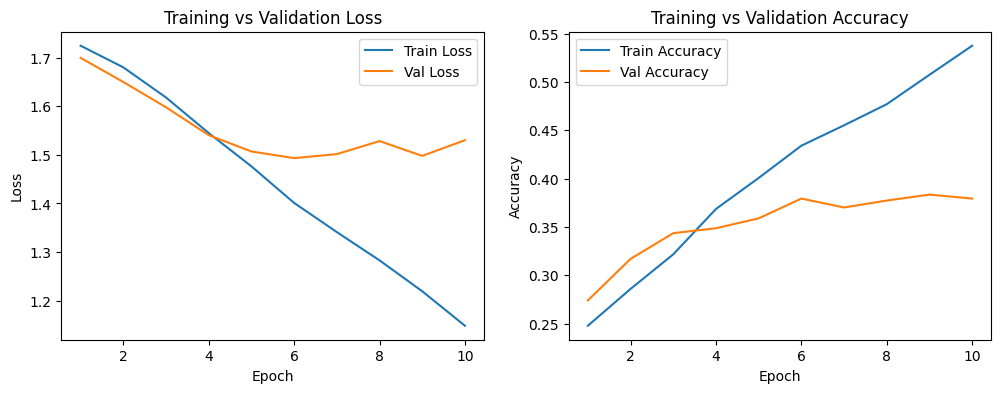

In [ ]:
import matplotlib.pyplot as plt

# Plot training versus validation loss and accuracy.
epoch_indices = range(1, len(train_losses) + 1)
# Final evaluation on the held-out test set using the best model.
test_loss, test_acc = evaluate(model, test_loader, loss_function, device)
print(f"Final Train Loss: {train_loss:.3f}, Train Accuracy: {train_acc:.3f}")
print(f"Final Val Loss: {val_loss:.3f}, Val Accuracy: {val_acc:.3f}")
print(f"Final Test Loss: {test_loss:.3f}, Test Accuracy: {test_acc:.3f}")
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1) #splits it into two graphs
plt.plot(epoch_indices, train_losses, label="Train Loss")
plt.plot(epoch_indices, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1, 2, 2) #splits it into two graphs
plt.plot(epoch_indices, train_accuracies, label="Train Accuracy")
plt.plot(epoch_indices, val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

The model accuracy finished at a 37.6% chance to correctly determine which character spoke the line after 10 epochs. This is over twice as accurate compared to guessing at random (16.7%), an outcome I am pleased with.

In [ ]:
# Grid Search 1: Learning rate and weight decay for optimizer.
learning_rates = [3e-4, 1e-3, 3e-3] #I feel so smart using scientific notation
weight_decays = [0.0, 1e-5]

#Results of the learning rate/weight decay test
grid_results_lr_wd = []

for lr in learning_rates:
    for wd in weight_decays:
        model = FFXIVLSTMClassifier(
            vocab_size=vocab_size,
            embedding_dim=embedding_dim,
            hidden_size=hidden_size,
            num_classes=num_classes,
            pad_idx=pad_idx,
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        best_val_accuracy_for_setting = 0.0

        for epoch in range(5):  # shorter runs for grid search for speed
            train_loss, train_acc = train_one_epoch(
                model, train_loader, optimizer, loss_function, device
            )
            val_loss, val_acc = evaluate(model, val_loader, loss_function, device)

            print(f"Epoch {epoch + 1}: val_acc={val_acc:.4f}")
            best_val_accuracy_for_setting = max(best_val_accuracy_for_setting, val_acc)

        grid_results_lr_wd.append((lr, wd, best_val_accuracy_for_setting))

print("\n=== Grid Search 1 Results (learning rate, weight decay) ===")
for lr, wd, acc in grid_results_lr_wd:
    print(f"learning_rate={lr}, weight_decay={wd} => best val accuracy = {acc:.3f}")


Epoch 1: val_acc=0.2587
Epoch 2: val_acc=0.2669
Epoch 3: val_acc=0.2802
Epoch 4: val_acc=0.2894
Epoch 5: val_acc=0.3057
Epoch 1: val_acc=0.2536
Epoch 2: val_acc=0.2587
Epoch 3: val_acc=0.2638
Epoch 4: val_acc=0.2710
Epoch 5: val_acc=0.3047
Epoch 1: val_acc=0.2781
Epoch 2: val_acc=0.2924
Epoch 3: val_acc=0.3374
Epoch 4: val_acc=0.3517
Epoch 5: val_acc=0.3497
Epoch 1: val_acc=0.2597
Epoch 2: val_acc=0.2965
Epoch 3: val_acc=0.3016
Epoch 4: val_acc=0.3333
Epoch 5: val_acc=0.3548
Epoch 1: val_acc=0.3119
Epoch 2: val_acc=0.3466
Epoch 3: val_acc=0.3415
Epoch 4: val_acc=0.3773
Epoch 5: val_acc=0.3517
Epoch 1: val_acc=0.3200
Epoch 2: val_acc=0.3456
Epoch 3: val_acc=0.3661
Epoch 4: val_acc=0.3599
Epoch 5: val_acc=0.3548

=== Grid Search 1 Results (learning rate, weight decay) ===
learning_rate=0.0003, weight_decay=0.0 => best val accuracy = 0.306
learning_rate=0.0003, weight_decay=1e-05 => best val accuracy = 0.305
learning_rate=0.001, weight_decay=0.0 => best val accuracy = 0.352
learning_rate=

In [ ]:
# Grid Search 2: Embedding dimension and hidden size for the LSTM model.
embedding_dim_candidates = [64, 128]
hidden_size_candidates = [64, 128]

grid_results_embed_hidden = []

for candidate_embedding_dim in embedding_dim_candidates:
    for candidate_hidden_size in hidden_size_candidates:
        print(f"\n=== Running embed_dim={candidate_embedding_dim}, hidden_dim={candidate_hidden_size} ===")

        model = FFXIVLSTMClassifier(
            vocab_size=vocab_size,
            embedding_dim=candidate_embedding_dim,
            hidden_size=candidate_hidden_size,
            num_classes=num_classes,
            pad_idx=pad_idx,
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
        best_val_accuracy_for_setting = 0.0

        for epoch in range(5):   # short runs for architecture search
            train_loss, train_acc = train_one_epoch(
                model,
                train_loader,
                optimizer,
                loss_function,
                device,
            )
            val_loss, val_acc = evaluate(model, val_loader, loss_function, device)

            print(f"Epoch {epoch + 1}: val_acc={val_acc:.4f}")
            best_val_accuracy_for_setting = max(best_val_accuracy_for_setting, val_acc)

        grid_results_embed_hidden.append(
            (candidate_embedding_dim, candidate_hidden_size, best_val_accuracy_for_setting)
        )

print("\n=== Grid Search 2 Results (embedding_dim, hidden_dim) ===")
for emb_dim, hid_dim, acc in grid_results_embed_hidden:
    print(f"embed_dim={emb_dim}, hidden_dim={hid_dim} → best val accuracy = {acc:.4f}")



=== Running embed_dim=64, hidden_dim=64 ===
Epoch 1: val_acc=0.2689
Epoch 2: val_acc=0.2986
Epoch 3: val_acc=0.3282
Epoch 4: val_acc=0.3466
Epoch 5: val_acc=0.3425

=== Running embed_dim=64, hidden_dim=128 ===
Epoch 1: val_acc=0.2689
Epoch 2: val_acc=0.3129
Epoch 3: val_acc=0.3487
Epoch 4: val_acc=0.3558
Epoch 5: val_acc=0.3599

=== Running embed_dim=128, hidden_dim=64 ===
Epoch 1: val_acc=0.2802
Epoch 2: val_acc=0.3098
Epoch 3: val_acc=0.3466
Epoch 4: val_acc=0.3497
Epoch 5: val_acc=0.3732

=== Running embed_dim=128, hidden_dim=128 ===
Epoch 1: val_acc=0.2924
Epoch 2: val_acc=0.3425
Epoch 3: val_acc=0.3446
Epoch 4: val_acc=0.3476
Epoch 5: val_acc=0.3763

=== Grid Search 2 Results (embedding_dim, hidden_dim) ===
embed_dim=64, hidden_dim=64 → best val accuracy = 0.3466
embed_dim=64, hidden_dim=128 → best val accuracy = 0.3599
embed_dim=128, hidden_dim=64 → best val accuracy = 0.3732
embed_dim=128, hidden_dim=128 → best val accuracy = 0.3763


# **4.)**
To get extra points, I removed the top K most-used words (according to the Python dictionary) from the experiment to see how it changed the outcome. The thought process behind it was that cuttingout the “a’s” and “for’s” would increase the proportion of unique or semi-unique words thus bump up accuracy; for example, “Eulmore” is primarily said by Alphinaud and Gra’ha Tia, so every time the model saw that keyword it would be more likely to correctly predict one of those two as the speaker. As shown by the graph, at its best (K= 10) it actually performed near-identically to the baseline validation accuracy. When testing with K > 25 the accuracy was even lower.

In [ ]:
from collections import Counter

print(f"\n=== Special-word statistics (unique per speaker AND not in top 10 common list) ===")

# Global frequency over all chosen speakers
global_word_freq = Counter()
for speaker_name, word_freqs in speaker_word_freqs.items():
    global_word_freq.update(word_freqs)

TOP_K_COMMON = 10
common_words = {word for word, count in global_word_freq.most_common(TOP_K_COMMON)}

for speaker_name in speaker_order:
    if speaker_name not in speaker_word_freqs:
        continue

    freq_counter = speaker_word_freqs[speaker_name]
    total_words_for_speaker = speaker_token_counts[speaker_name]

    special_word_types = [
        word for word, speakers in word_speakers.items()
        if speakers == {speaker_name} and word not in common_words
    ]
    num_special_word_types = len(special_word_types)

    special_word_occurrences = sum(freq_counter[word] for word in special_word_types)
    percent_special = (
        100.0 * special_word_occurrences / total_words_for_speaker
        if total_words_for_speaker > 0 else 0.0
    )

    print(f"\nSpeaker: {speaker_name}")
    print(f"  Total words: {total_words_for_speaker}")
    print(f"  Special word types (unique + non-dictionary): {num_special_word_types}")
    print(f"  Special word occurrences: {special_word_occurrences}")
    print(f"  % of speaker's words that are special: {percent_special:.2f}%")


=== Special-word statistics (unique per speaker AND not in top 10 common list) ===

Speaker: Alphinaud
  Total words: 44491
  Special word types (unique + non-dictionary): 1214
  Special word occurrences: 1471
  % of speaker's words that are special: 3.31%

Speaker: Y'shtola
  Total words: 27414
  Special word types (unique + non-dictionary): 781
  Special word occurrences: 941
  % of speaker's words that are special: 3.43%

Speaker: Alisaie
  Total words: 36581
  Special word types (unique + non-dictionary): 895
  Special word occurrences: 1106
  % of speaker's words that are special: 3.02%

Speaker: Urianger
  Total words: 21281
  Special word types (unique + non-dictionary): 907
  Special word occurrences: 1626
  % of speaker's words that are special: 7.64%

Speaker: G'raha Tia
  Total words: 32525
  Special word types (unique + non-dictionary): 847
  Special word occurrences: 1013
  % of speaker's words that are special: 3.11%

Speaker: Emet-Selch
  Total words: 10861
  Special wo

In [ ]:
from collections import Counter
from torch.utils.data import Dataset, DataLoader

# Estimate how often each word ID appears in the encoded training set.
# This is used to decide which words count as "common dictionary words".
word_id_counts = Counter()

for input_id_tensor, label_id in train_dataset:
    # Convert the tensor of ids into a plain Python list.
    word_id_list = input_id_tensor.tolist()
    for word_id in word_id_list:
        # Ignore padding ids, since those are not real words.
        if word_id == pad_idx:
            continue
        word_id_counts[word_id] += 1

# Pick the top-K most frequent word IDs as "common" words.
# Words outside this set will be treated as more character-specific.
TOP_K_COMMON = 10  # can increase for a looser definition of "special"
common_word_ids = {word_id for word_id, count in word_id_counts.most_common(TOP_K_COMMON)}

# Dataset wrapper that can mask common or special words at the ID level.
# This makes it easy to run ablation experiments without changing the core model.
class MaskedFFXIVDataset(Dataset):
    def __init__(self, base_dataset, common_word_ids, pad_idx, mode="baseline"):
        self.base_dataset = base_dataset
        self.common_word_ids = common_word_ids
        self.pad_idx = pad_idx
        assert mode in ["baseline", "keep_special_only", "keep_common_only"]
        self.mode = mode

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        # Grab the original encoded sentence and its label.
        input_id_tensor, label_id = self.base_dataset[idx]

        # No masking: return the original data.
        if self.mode == "baseline":
            return input_id_tensor, label_id

        # Clone so the original dataset stays untouched.
        masked_ids = input_id_tensor.clone()

        # Walk over every position in the sequence and optionally mask it.
        for position_index, word_id in enumerate(masked_ids):
            # Padding stays padding.
            if word_id == self.pad_idx:
                continue

            is_common_word = int(word_id) in self.common_word_ids

            # For "keep_special_only", common words are replaced by padding.
            if self.mode == "keep_special_only" and is_common_word:
                masked_ids[position_index] = self.pad_idx

            # For "keep_common_only", special words are replaced by padding.
            elif self.mode == "keep_common_only" and not is_common_word:
                masked_ids[position_index] = self.pad_idx

        return masked_ids, label_id

Ignoring the 10 most-used words when defining 'special' words.


In [ ]:
batch_size = 128  # same batch size as the main experiments

# Baseline: no masking at all.
train_dataset_baseline = MaskedFFXIVDataset(
    train_dataset, common_word_ids, pad_idx, mode="baseline"
)
val_dataset_baseline = MaskedFFXIVDataset(
    val_dataset, common_word_ids, pad_idx, mode="baseline"
)

# Special-only: common / dictionary words are masked out.
train_dataset_special_only = MaskedFFXIVDataset(
    train_dataset, common_word_ids, pad_idx, mode="keep_special_only"
)
val_dataset_special_only = MaskedFFXIVDataset(
    val_dataset, common_word_ids, pad_idx, mode="keep_special_only"
)

train_loader_baseline = DataLoader(
    train_dataset_baseline, batch_size=batch_size, shuffle=True
)
val_loader_baseline = DataLoader(
    val_dataset_baseline, batch_size=batch_size, shuffle=False
)

train_loader_special_only = DataLoader(
    train_dataset_special_only, batch_size=batch_size, shuffle=True
)
val_loader_special_only = DataLoader(
    val_dataset_special_only, batch_size=batch_size, shuffle=False
)


In [ ]:
def run_experiment(train_loader, val_loader, num_epochs, experiment_name):

    model = FFXIVLSTMClassifier(
        vocab_size=vocab_size,
        embedding_dim=embedding_dim,
        hidden_size=hidden_size,
        num_classes=num_classes,
        pad_idx=pad_idx,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss()

    train_accuracies = []
    val_accuracies = []

    for epoch_index in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
        )
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(
            f"Epoch {epoch_index + 1}/{num_epochs} - "
            f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}"
        )

    return model, train_accuracies, val_accuracies

Epoch 1/10 - train_acc=0.2407, val_acc=0.2761
Epoch 2/10 - train_acc=0.2775, val_acc=0.2802
Epoch 3/10 - train_acc=0.2972, val_acc=0.3016
Epoch 4/10 - train_acc=0.3407, val_acc=0.3517
Epoch 5/10 - train_acc=0.3827, val_acc=0.3661
Epoch 6/10 - train_acc=0.4177, val_acc=0.3661
Epoch 7/10 - train_acc=0.4466, val_acc=0.3640
Epoch 8/10 - train_acc=0.4772, val_acc=0.3650
Epoch 9/10 - train_acc=0.5082, val_acc=0.3640
Epoch 10/10 - train_acc=0.5409, val_acc=0.3323
Epoch 1/10 - train_acc=0.2500, val_acc=0.2566
Epoch 2/10 - train_acc=0.2701, val_acc=0.2751
Epoch 3/10 - train_acc=0.3043, val_acc=0.2863
Epoch 4/10 - train_acc=0.3519, val_acc=0.3364
Epoch 5/10 - train_acc=0.3870, val_acc=0.3344
Epoch 6/10 - train_acc=0.4159, val_acc=0.3579
Epoch 7/10 - train_acc=0.4513, val_acc=0.3661
Epoch 8/10 - train_acc=0.4831, val_acc=0.3558
Epoch 9/10 - train_acc=0.5129, val_acc=0.3753
Epoch 10/10 - train_acc=0.5385, val_acc=0.3661


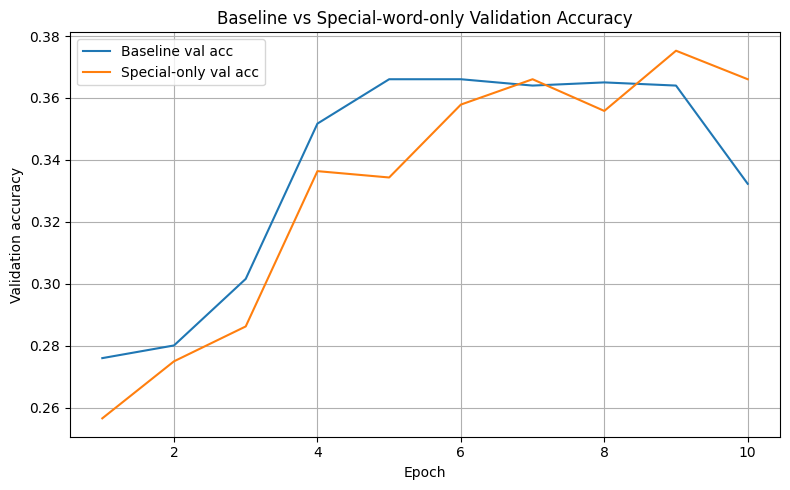

In [ ]:
num_epochs = 10


# Baseline experiment: full text, no masking.
baseline_model, baseline_train_accs, baseline_val_accs = run_experiment(
    train_loader_baseline,
    val_loader_baseline,
    num_epochs,
    experiment_name="Baseline (full text)",
)

# Special-only experiment: common dictionary words masked out.
special_model, special_train_accs, special_val_accs = run_experiment(
    train_loader_special_only,
    val_loader_special_only,
    num_epochs,
    experiment_name="Only special (non-dictionary) words",
)


# --- Plot validation accuracy curves ---
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, baseline_val_accs, label="Baseline val acc")
plt.plot(epochs, special_val_accs, label="Special-only val acc")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Baseline vs Special-word-only Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()